# This is an Online Shopping Prediction Project 

In this Particular Project we will try to train a model that will predict
Whether a Person Visiting an Online Store will do Purchase or Not 

# 1- Problem Defination

we are making prediction on dataset whether a Customer will make Onine Purchase or Not 

# 2- Data 

# 3- Evaluate

In Intial stages we need to make sure if our model gives us accuracy of 95%

# 4- Features 

what are columns giving us Information we need to understand the importance of each column

# Tools Prepartion 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns     
%matplotlib inline 
# Importing models of sklearn 
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier 
# Import Evaluation Libraries 
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score,recall_score,f1_score
from sklearn.metrics import confusion_matrix

# Exploring the Data Initial Stage

# Importing DataSet 

In [2]:
df = pd.read_csv("online_shoppers_intention.csv")
df.shape

(12330, 18)

This data has 12330 Rows and 18 Columns 

# Exploring the DataSet

In [3]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,1,1,1,1,0,0,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,2,2,2,1,2,0,0,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,4,1,9,3,0,0,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,2,3,2,2,4,0,0,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,2,3,3,1,4,0,1,0


In [4]:
df.tail()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,12,4,6,1,1,0,1,0
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,11,3,2,1,8,0,1,0
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,11,3,2,1,13,0,1,0
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,11,2,2,3,11,0,0,0
12329,0,0.0,0,0.0,3,21.250000,0.000000,0.066667,0.000000,0.0,11,3,2,1,2,1,1,0


In [5]:
df.dtypes

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                        int64
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                  int64
Weekend                      int64
Revenue                      int64
dtype: object

In [6]:
# Checking Zeros and 1s in Revenue 
df["Revenue"].value_counts()
# here 0 means no shopping and 1s means shopping 

Revenue
0    10422
1     1908
Name: count, dtype: int64

Plotting the Values 

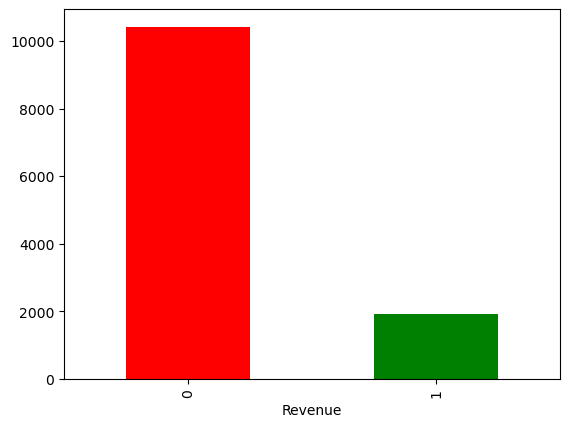

In [7]:
df["Revenue"].value_counts().plot(kind = 'bar', color=["red","green"]);

In [8]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,7.651987,2.124006,2.357097,3.147364,4.069586,0.151176,0.232603,0.154745
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,3.392841,0.911325,1.717277,2.401591,4.025169,0.376989,0.422509,0.361676
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,5.000000,2.000000,2.000000,1.000000,2.000000,0.000000,0.000000,0.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,7.000000,2.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,11.000000,3.000000,2.000000,4.000000,4.000000,0.000000,0.000000,0.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,12.000000,8.000000,13.000000,9.000000,20.000000,2.000000,1.000000,1.000000


In [9]:
df.Weekend.value_counts()

Weekend
0    9462
1    2868
Name: count, dtype: int64

In [10]:
9462/12330

0.767396593673966

In [11]:
pd.crosstab(df.Revenue,df.Weekend)

Weekend,0,1
Revenue,,
0,8053,2369
1,1409,499


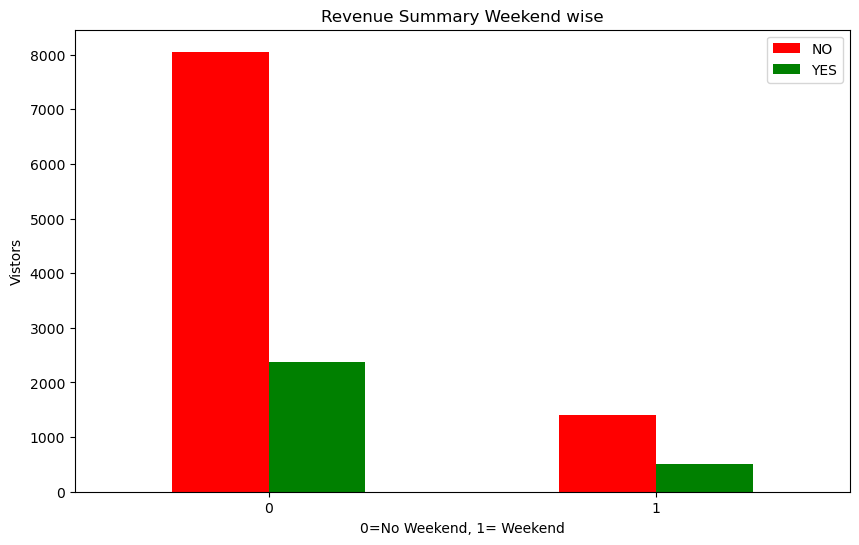

In [12]:
pd.crosstab(df.Revenue,df.Weekend).plot(kind='bar',
                                  figsize=(10,6),
                                  color=["red","green"])
plt.title('Revenue Summary Weekend wise')
plt.xlabel("0=No Weekend, 1= Weekend")
plt.ylabel("Vistors")
plt.legend(["NO","YES"])
plt.xticks(rotation=0);

From the Above we can see Weekend doesn't have much effect on shopping 

# Now Checking Special DAY with Revenue

In [13]:
df.SpecialDay.value_counts()

SpecialDay
0.0    11079
0.6      351
0.8      325
0.4      243
0.2      178
1.0      154
Name: count, dtype: int64

In [14]:
pd.crosstab(df.Revenue,df.SpecialDay)

SpecialDay,0.0,0.2,0.4,0.6,0.8,1.0
Revenue,,,,,,
0,9248,164,230,322,314,144
1,1831,14,13,29,11,10


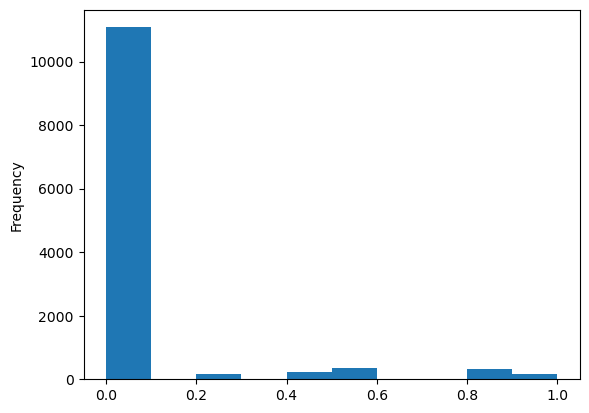

In [15]:
# create Histogram to see SpecialDay Distribution
df.SpecialDay.plot.hist();

Here we can see data is baised on 1st Special Day 

Drawing Correlation Map to See which feature has great impact on Data

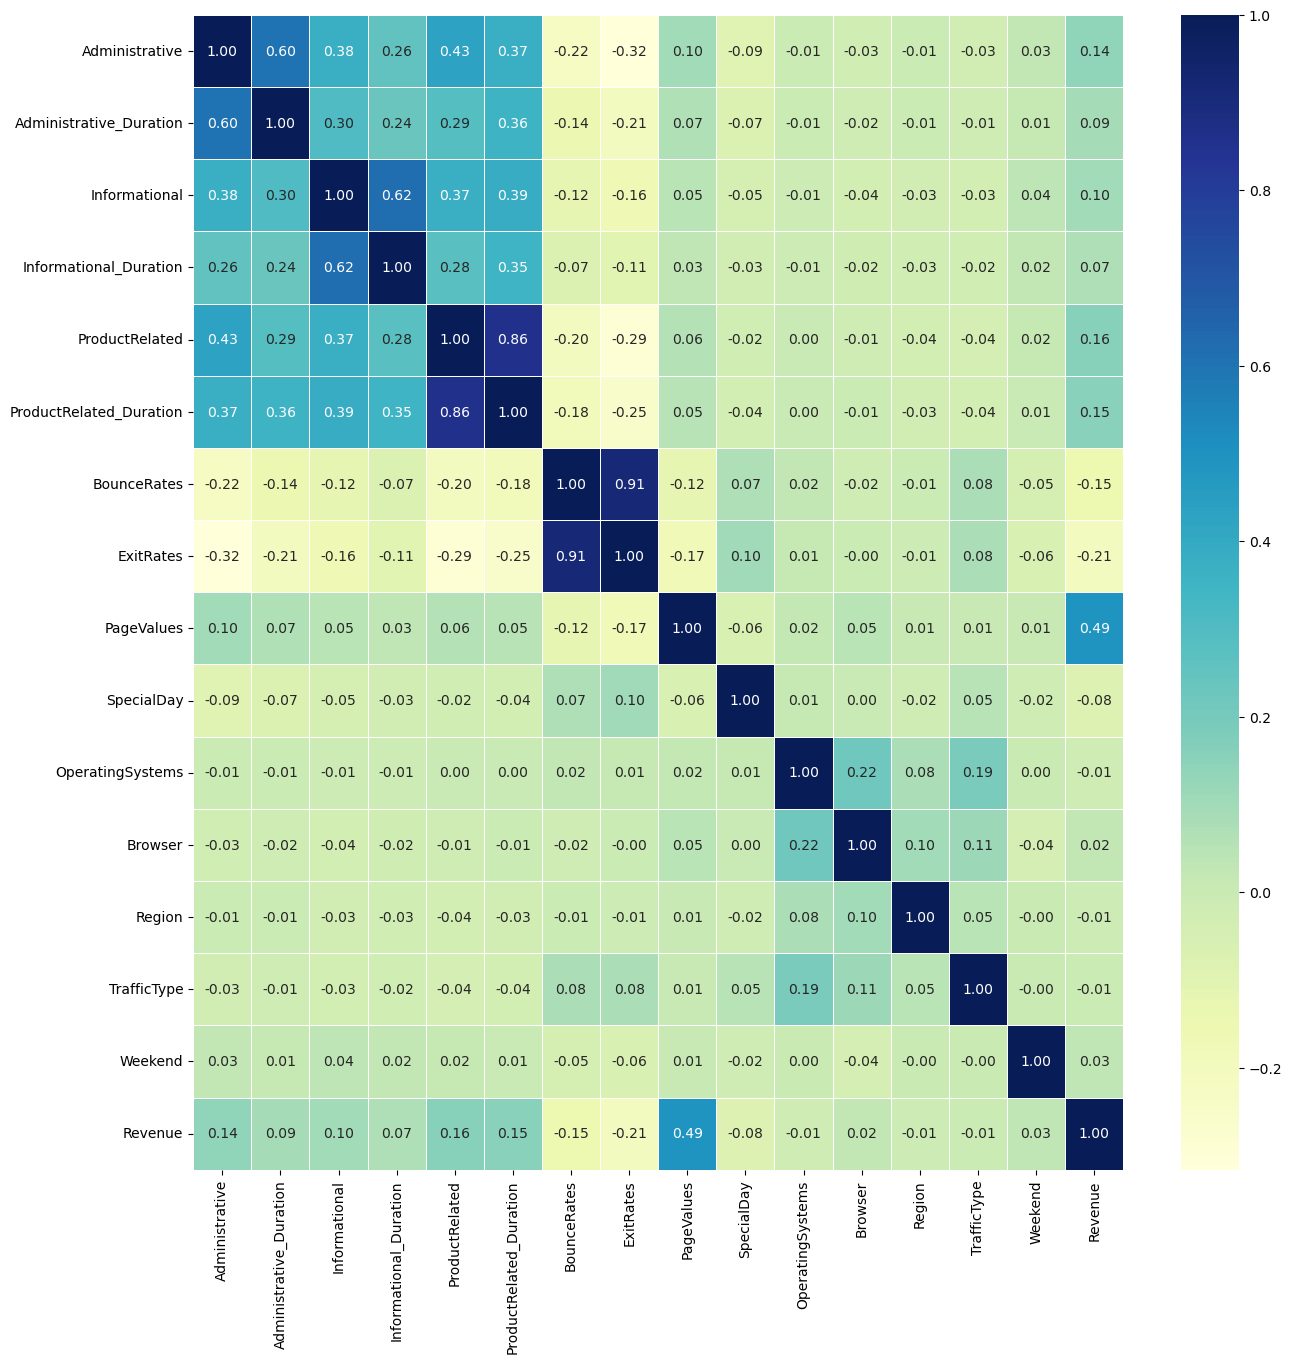

In [16]:
# lets draw Correlation Map
#positive means if value increase it will also increase its corresponding value 
#negative means of value increase it will decrease its corresponding value
dlf = df.drop(['Month','VisitorType'], axis=1)
cor_map = dlf.corr()
home,room = plt.subplots(figsize=(15,15))
room = sns.heatmap(cor_map,
                  annot=True,
                  linewidths=0.5,
                  fmt="0.2f",
                  cmap="YlGnBu");

# 5-Modeling

# The Models we are going to use 
1. K-Nearest Neighbours Classifers
2. Naive Bayes
3. Random Forest Classifiers
4. Logistic Regression
5. Neural Network

# 1.KNeighborsClassifier

In [17]:
X=df.drop("Revenue",axis=1)
y=df["Revenue"]
# Fixing the Value so it doesnot change
np.random.seed(0)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=3)  # by changing the random state accuracy varies 
knn  = KNeighborsClassifier(n_neighbors=11)
knn.fit(X_train,y_train)
result = knn.score(X_test,y_test)
print(f"The Accuracy Score of KNeighborsClassifiers is {result}")
print(f"In Percentage {result*100}")

y_pred = knn.predict(X_test)

# precision Score 
pscore = precision_score(y_test,y_pred)

print(f"Precision Score of Model is : {pscore}")

#Recall Score 

rscore = recall_score(y_test,y_pred)

print(f"Recall Score of Model is : {rscore}")


#f1 Score
fscore = f1_score(y_test,y_pred)

print(f"f1 score of Model is : {fscore}")

The Accuracy Score of KNeighborsClassifiers is 0.8718572587185726
In Percentage 87.18572587185726
Precision Score of Model is : 0.7211538461538461
Recall Score of Model is : 0.20718232044198895
f1 score of Model is : 0.3218884120171674


# 2.Naive Bayes

In [18]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)
gnb= GaussianNB()
gnb.fit(X_train,y_train)
result = gnb.score(X_test,y_test)
print(f"The Accuracy Score of Naive Bayes is {result}")
print(f"In Percentage {result*100}")



y_pred = gnb.predict(X_test)

# precision Score 
pscore = precision_score(y_test,y_pred)

print(f"Precision Score of Model is : {pscore}")

#Recall Score 

rscore = recall_score(y_test,y_pred)

print(f"Recall Score of Model is : {rscore}")


#f1 Score
fscore = f1_score(y_test,y_pred)

print(f"f1 score of Model is : {fscore}")

The Accuracy Score of Naive Bayes is 0.8369829683698297
In Percentage 83.69829683698296
Precision Score of Model is : 0.5239234449760766
Recall Score of Model is : 0.518957345971564
f1 score of Model is : 0.5214285714285715


# 3.Random Forest Classifiers

In [19]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)
rgc= RandomForestClassifier()
rgc.fit(X_train,y_train)
result = rgc.score(X_test,y_test)
print(f"The Accuracy Score of RandomForestClassifier is {result}")
print(f"In Percentage {result*100}")


y_pred = rgc.predict(X_test)

# precision Score 
pscore = precision_score(y_test,y_pred)

print(f"Precision Score of Model is : {pscore}")

#Recall Score 

rscore = recall_score(y_test,y_pred)

print(f"Recall Score of Model is : {rscore}")


#f1 Score
fscore = f1_score(y_test,y_pred)

print(f"f1 score of Model is : {fscore}")

The Accuracy Score of RandomForestClassifier is 0.902676399026764
In Percentage 90.2676399026764
Precision Score of Model is : 0.7408759124087592
Recall Score of Model is : 0.5456989247311828
f1 score of Model is : 0.628482972136223


# 4.Logistic Regression

In [20]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)
lgc= LogisticRegression()
lgc.fit(X_train,y_train)
result = lgc.score(X_test,y_test)
print(f"The Accuracy Score of LogisticRegression is {result}")
print(f"In Percentage {result*100}")

y_pred = lgc.predict(X_test)

# precision Score 
pscore = precision_score(y_test,y_pred)

print(f"Precision Score of Model is : {pscore}")

#Recall Score 

rscore = recall_score(y_test,y_pred)

print(f"Recall Score of Model is : {rscore}")


#f1 Score
fscore = f1_score(y_test,y_pred)

print(f"f1 score of Model is : {fscore}")

The Accuracy Score of LogisticRegression is 0.8799675587996756
In Percentage 87.99675587996757
Precision Score of Model is : 0.7071823204419889
Recall Score of Model is : 0.3450134770889488
f1 score of Model is : 0.463768115942029


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Here we have a problem since data set is too big so model cannot iterate whole dataset 

# 5. Neural Network 

In [21]:
import numpy as np
import pandas as pd  # In case X_train and X_dev are pandas DataFrames

# Initialize weights and biases for the neural network layers
def init_params(input_size, hidden_size, output_size, lambda_):
    w1 = np.random.randn(hidden_size, input_size) * np.sqrt(2 / input_size)  # He initialization
    b1 = np.zeros((hidden_size, 1))
    w2 = np.random.randn(output_size, hidden_size) * np.sqrt(2 / hidden_size)
    b2 = np.zeros((output_size, 1))
    return w1, b1, w2, b2

# ReLU activation function
def ReLU(Z):
    return np.maximum(0, Z)

# Softmax function for multi-class classification
def softmax(Z):
    expZ = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return expZ / np.sum(expZ, axis=0, keepdims=True)

# Forward propagation function
def forward_prop(w1, b1, w2, b2, X):
    Z1 = np.dot(w1, X) + b1
    A1 = ReLU(Z1)
    Z2 = np.dot(w2, A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

# One-hot encoding function for labels
def one_hot(Y):
    Y = Y.astype(int)
    one_hot_Y = np.zeros((Y.max() + 1, Y.size))
    one_hot_Y[Y, np.arange(Y.size)] = 1
    return one_hot_Y

# Derivative of ReLU
def deriv_ReLU(Z):
    return Z > 0

# Backpropagation function
def back_prop(Z1, A1, Z2, A2, w2, X, Y, w1, lambda_):
    m = Y.size
    one_hot_Y = one_hot(Y)

    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m * np.dot(dZ2, A1.T) + (lambda_ / m) * w2
    db2 = 1 / m * np.sum(dZ2, axis=1, keepdims=True)

    dZ1 = np.dot(w2.T, dZ2) * deriv_ReLU(Z1)
    dW1 = 1 / m * np.dot(dZ1, X.T) + (lambda_ / m) * w1
    db1 = 1 / m * np.sum(dZ1, axis=1, keepdims=True)

    return dW1, db1, dW2, db2

# Update parameters function
def update_params(w1, b1, w2, b2, dW1, db1, dW2, db2, alpha):
    w1 -= alpha * dW1
    b1 -= alpha * db1
    w2 -= alpha * dW2
    b2 -= alpha * db2
    return w1, b1, w2, b2

# Get class predictions
def get_predictions(A2):
    return np.argmax(A2, axis=0)

# Calculate accuracy
def get_accuracy(predictions, Y):
    return np.mean(predictions == Y)

# Gradient descent function
def gradient_descent(X, Y, iterations, alpha, lambda_):
    input_size = X.shape[0]
    hidden_size = 400
    output_size = int(np.max(Y) + 1)

    w1, b1, w2, b2 = init_params(input_size, hidden_size, output_size, lambda_)

    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(w1, b1, w2, b2, X)
        dW1, db1, dW2, db2 = back_prop(Z1, A1, Z2, A2, w2, X, Y, w1, lambda_)
        w1, b1, w2, b2 = update_params(w1, b1, w2, b2, dW1, db1, dW2, db2, alpha)

        if i % 50 == 0:
            predictions = get_predictions(A2)
            accuracy = get_accuracy(predictions, Y)
            print(f"Iteration {i}: Accuracy = {accuracy:.4f}")

    return w1, b1, w2, b2

# Normalize data and convert to numpy arrays if needed
def normalize_data(X):
    if isinstance(X, pd.DataFrame):
        X = X.to_numpy()
    X = (X - np.mean(X, axis=1, keepdims=True)) / np.std(X, axis=1, keepdims=True)
    return X

# Example data (replace with actual training and validation sets)
np.random.seed(42)  # For reproducibility
X_train = np.random.rand(10, 1000)  # Example feature set with 10 features and 1000 samples
Y_train = np.random.randint(0, 3, 1000)  # Example labels with 3 classes
X_dev = np.random.rand(10, 200)  # Validation feature set
Y_dev = np.random.randint(0, 3, 200)  # Validation labels

# Normalize datasets
X_train = normalize_data(X_train)
X_dev = normalize_data(X_dev)

# Regularization strength
lambda_ = 0.3

# Train the model
w1, b1, w2, b2 = gradient_descent(X_train, Y_train, iterations=1000, alpha=0.8, lambda_=lambda_)

# Test the model on the validation set
_, _, _, A2_dev = forward_prop(w1, b1, w2, b2, X_dev)
predictions_dev = get_predictions(A2_dev)
accuracy_dev = get_accuracy(predictions_dev, Y_dev)
print(f"Test Set Accuracy = {accuracy_dev:.4f}")


Iteration 0: Accuracy = 0.3650
Iteration 50: Accuracy = 0.4270
Iteration 100: Accuracy = 0.5410
Iteration 150: Accuracy = 0.5910
Iteration 200: Accuracy = 0.6130
Iteration 250: Accuracy = 0.6350
Iteration 300: Accuracy = 0.6580
Iteration 350: Accuracy = 0.6710
Iteration 400: Accuracy = 0.6830
Iteration 450: Accuracy = 0.7080
Iteration 500: Accuracy = 0.6650
Iteration 550: Accuracy = 0.6770
Iteration 600: Accuracy = 0.7400
Iteration 650: Accuracy = 0.7400
Iteration 700: Accuracy = 0.6640
Iteration 750: Accuracy = 0.7150
Iteration 800: Accuracy = 0.7330
Iteration 850: Accuracy = 0.7590
Iteration 900: Accuracy = 0.7360
Iteration 950: Accuracy = 0.7280
Test Set Accuracy = 0.2950


here we can see train accuracy is more than Test Accuracy it can be result of overfitting and outliers that we can see in histogram

# 6.Experiments:

## In this part we will see the methods how we can improve our model accuracy

# Confusion Matrix 

In [ ]:
sns.set(font_scale=1.5)

def plot_confusion(y_test,y_pred):
    "This will plot the Confusion Matrix"
    fig,ax = plt.subplots(figsize=(3,3))
    ax = sns.heatmap(confusion_matrix(y_test,y_pred),
                    annot=True,
                    cbar=False)

plot_confusion(y_test,y_pred)
    


# Conclusion 